## Feature Engineering
- Feature generation, including factors (X) and labels (Y)
- Correlation analysis, including factor vs factor, label vs label, and factor vs label
- Initial hyperparameter tuning, pick suitable hyperparameters for factors according to correlation with different labels

### Data Loading

In [1]:
from execution_timing.data_loading import read_raw_data, truncate_depth, holdout_split
from execution_timing.feature_engineering import Factors
from execution_timing.feature_engineering import Labels
import pandas as pd
import numpy as np

# load mbp data, generate factors and labels
data_mbp10 = read_raw_data('data_raw/nvda_mbp-10_2026-07-01.parquet')
data = truncate_depth(data_mbp10, 3)
data, data_holdout = holdout_split(data, holdout_mins=120, purge_ticks=0)
print(f'Original raw data shape: {data.shape}')


Original raw data shape: (1797483, 12)


In [2]:
factors_generator = Factors(data=data, data_depth=3)
labels_generator = Labels(data=data)

factors = factors_generator.generate_factors()
labels = labels_generator.generate_labels()

factor_cols = factors.columns.tolist()
labels_cols = labels.columns.tolist()

print(f'Factors shape: {factors.shape}')
print(f'Labels shape: {labels.shape}\n')

print(f"Factors \n {factor_cols}\n")
print(f"Labels \n {labels_cols}\n")


Factors shape: (1797483, 7)
Labels shape: (1797483, 7)

Factors 
 ['obi_weighted', 'spread', 'spread_deviation', 'ask_px_momentum', 'bid_px_momentum', 'vwap_mid_deviation_ask', 'vwap_mid_deviation_bid']

Labels 
 ['ask_return', 'ask_return_max', 'ask_return_min', 'ask_return_mean', 'ask_return_direction', 'ask_return_std', 'ask_return_log_std']



In [3]:
# concat raw data, factors, and labels into single dataframe
assert(len(data) == len(factors) == len(labels))
data = pd.concat([data, factors, labels], axis=1)
print(f"Raw data shape with factors and labels: {data.shape}\n")

Raw data shape with factors and labels: (1797483, 26)



In [4]:
# Rows with NaN:
# 1. warm-up rows: missing feature values because features have look_back_ticks
# 2. ending-rows: missing label values because labels have look_forward_ticks
mask_nan = data.isna().any(axis=1)
print(f"NaN rows: {mask_nan.sum()}\n")

# Drop NaN and resample down to 1 second
data = data[~mask_nan]
data_1s = data.resample(rule='1s').first().ffill()
data_1min = data_1s.resample(rule='60s').first().ffill()
print(f"Raw data shape after dropping NaN: {data.shape}")
print(f"Resampled data shape, 1s: {data_1s.shape}")
print(f"Resampled data shape, 1min: {data_1min.shape}")
# display(data_1min)
# display(data_1s)


NaN rows: 200

Raw data shape after dropping NaN: (1797283, 26)
Resampled data shape, 1s: (12597, 26)
Resampled data shape, 1min: (210, 26)


### Factor & Label Time series Plot

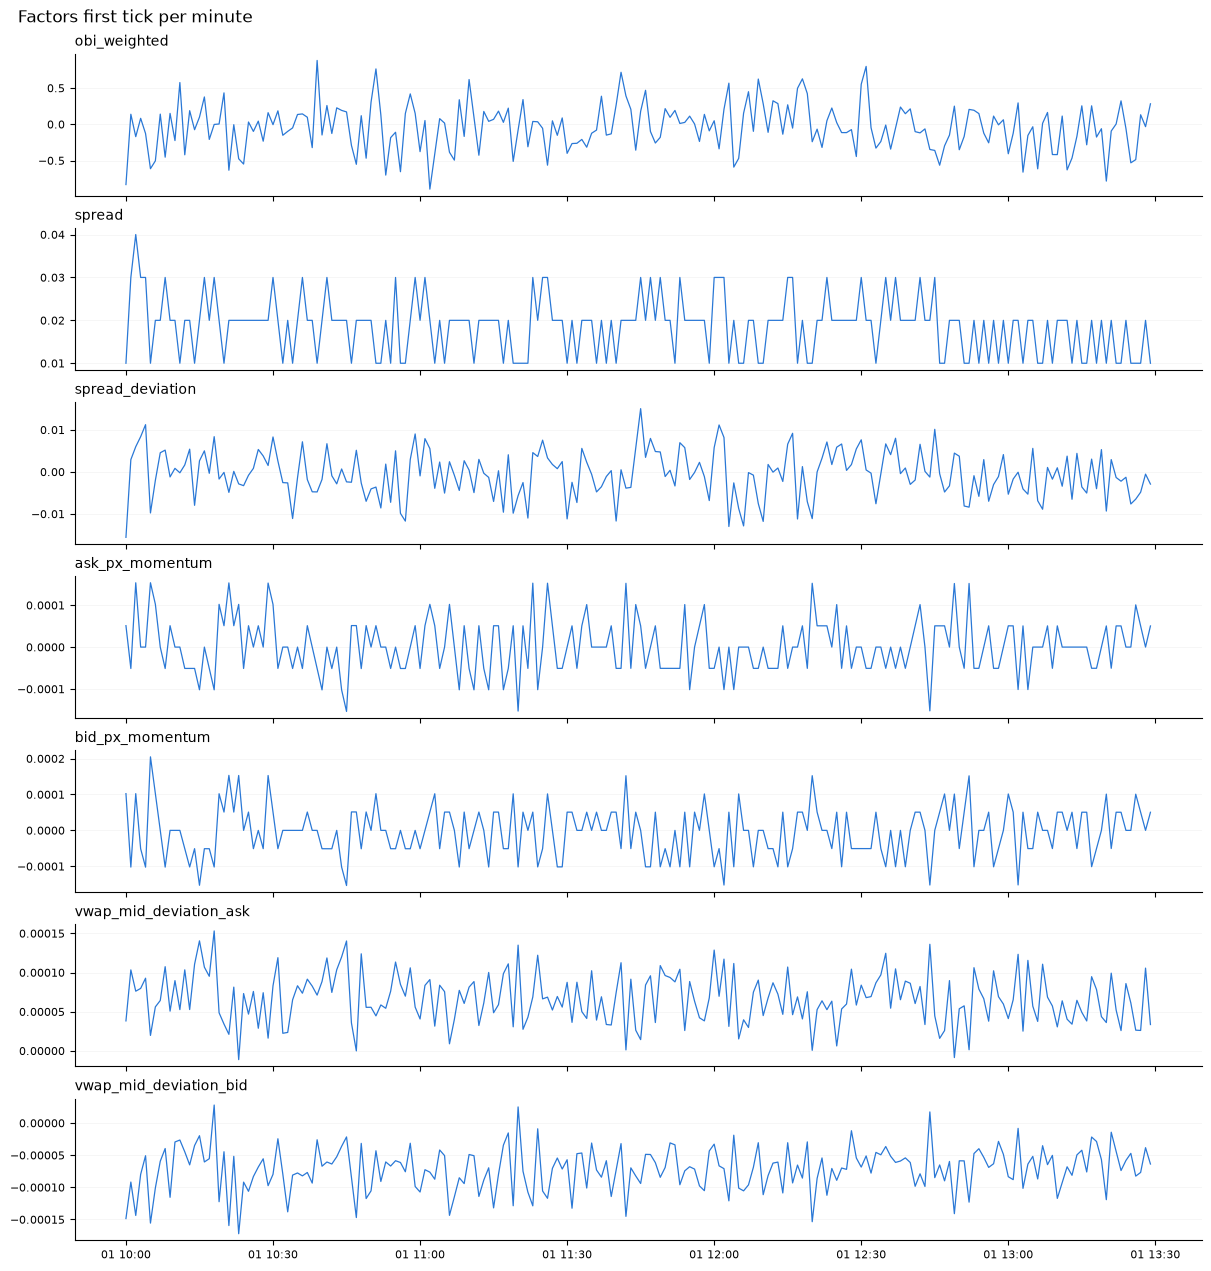

In [5]:
import execution_timing.visualization as visual

visual.plot_time_series(df=data_1min,
                        cols=factor_cols,
                        title='Factors')

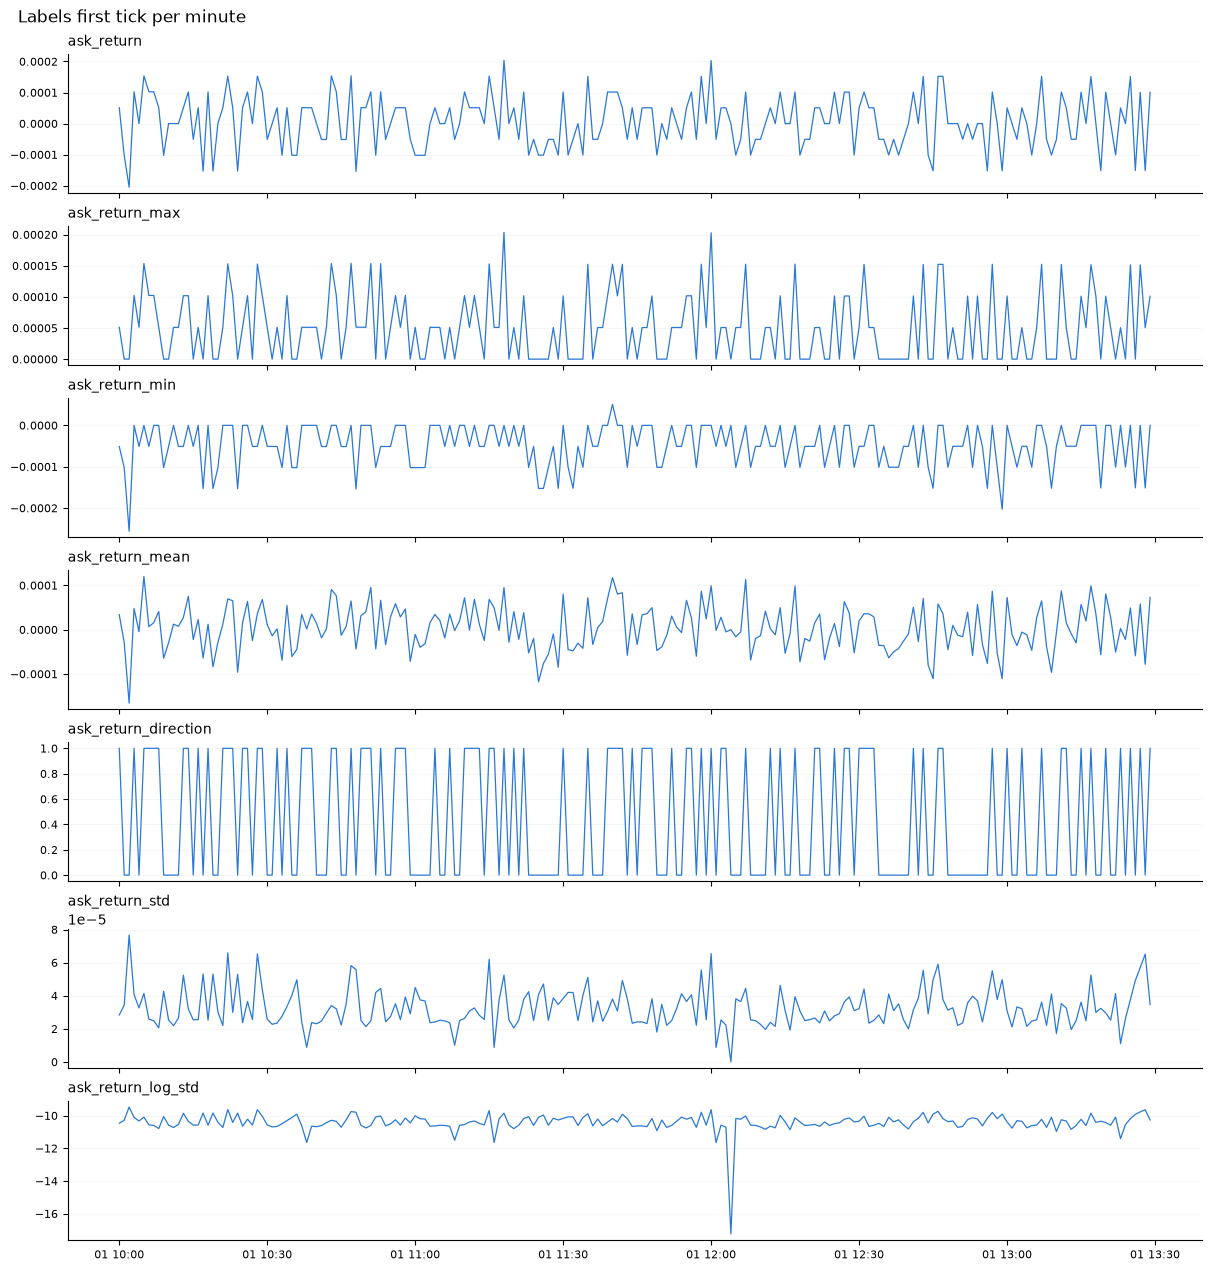

In [6]:
visual.plot_time_series(df=data_1min,
                        cols=labels_cols,
                        title='Labels')

### Factor correlation
- Strong correlation within each group: `vwap_mid_deviation_ask/bid`, `bid/ask_px_momentum`, and `spread/spread_deviation`
- `price momentum` and `vwap_mid_deviation` are correlated


**Explanation:** \
Multicollinearity inflates the variance of individual regression coefficients and makes the regression numerically unstable, but it hurts prediction much less — the fitted values depend only on the column space of the factors, not on how weight is split among correlated ones.

**The caveat:** \
This holds only while the factor correlation structure stays stable out-of-sample; a regime shift can turn the large offsetting coefficients into large prediction errors. Regularization (e.g. ridge) mitigates this.

In [7]:
# showing default hyperparameters
factors_generator.factor_hyperparameters

{'obi_weighted': {'level_weights': (50, 30, 20)},
 'spread': {},
 'spread_deviation': {'look_back_ticks': 100},
 'ask_px_momentum': {'lag_ticks': 100},
 'bid_px_momentum': {'lag_ticks': 100},
 'vwap_mid_deviation_ask': {'look_back_ticks': 100,
  'level_weights': (85, 10, 5)},
 'vwap_mid_deviation_bid': {'look_back_ticks': 100,
  'level_weights': (85, 10, 5)}}

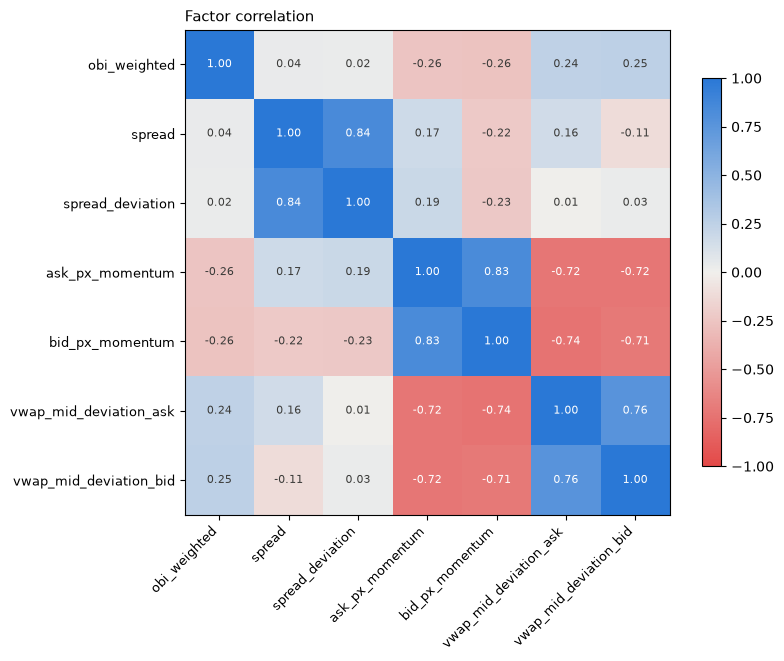

In [8]:
visual.plot_corr_heatmap(df=data_1s,
                         cols=factor_cols,
                         title='Factor correlation')

### Label Correlation

Labels are designed in a way such that they are correlated and redundant, the center focus is the future best ask price.

Labels are designed to capture two effects:
- **predicted pnl:** the pnl of best ask price if we choose to wait rather than executing now; including `ask_return`, `ask_return_min`, `ask_return_mean`, and `ask_return_direction`.
- **risk:** the risk if we choose to wait rather than executing now, including `ask_return_max`, `ask_return_std` and `ask_return_log_std`.


In [9]:
# showing label descriptions
for label_name, desc in labels_generator.label_desc.items():
    print(f"Label: {label_name}")
    print(f"{desc}")
    print()

Label: ask_return
Log return of the ask price after look_forward_ticks, calculated as ln(ask_{t+H} / ask_t).

Label: ask_return_max
Worst-case ask return of delaying the buy, calculated as ln(max(ask_{t+1..t+H}) / ask_t): the highest ask over the forecast horizon relative to the current ask. Represents the risk of the ask price going up while waiting; more positive means a bigger potential loss.

Label: ask_return_min
Best-case ask return of delaying the buy, calculated as ln(min(ask_{t+1..t+H}) / ask_t): the lowest ask over the forecast horizon relative to the current ask. Represents the maximum price improvement achievable by waiting with perfect timing; more negative means a bigger potential saving.

Label: ask_return_mean
Expected ask return of delaying the buy, calculated as ln(mean(ask_{t+1..t+H}) / ask_t): the average ask over the forecast horizon relative to the current ask. Negative means waiting is expected to get a better price; positive means buy now.

Label: ask_return_dir

In [10]:
# showing default hyperparameters
labels_generator.label_hyperparameters

{'ask_return': {'look_forward_ticks': 100},
 'ask_return_max': {'look_forward_ticks': 100},
 'ask_return_min': {'look_forward_ticks': 100},
 'ask_return_mean': {'look_forward_ticks': 100},
 'ask_return_direction': {'look_forward_ticks': 100},
 'ask_return_std': {'look_forward_ticks': 100},
 'ask_return_log_std': {'look_forward_ticks': 100}}

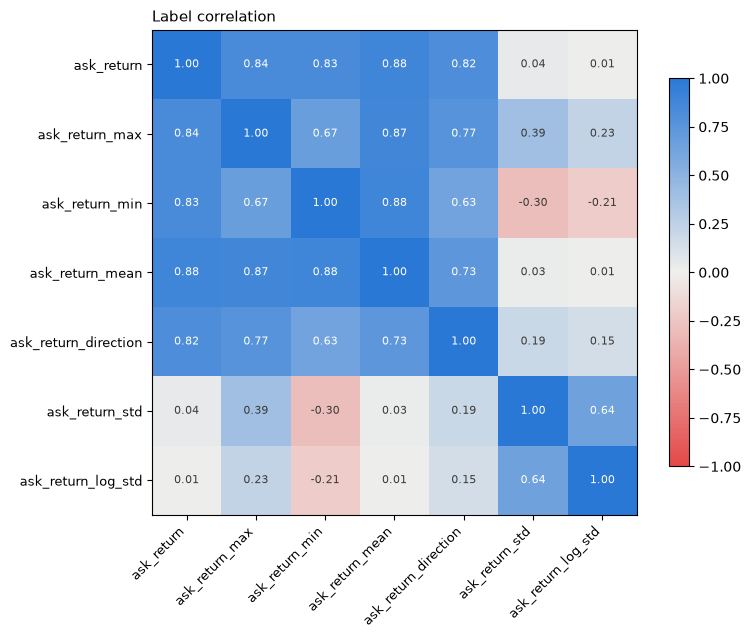

In [11]:
visual.plot_corr_heatmap(df=data_1s,
                         cols=labels_cols,
                         title='Label correlation')

### Factor & Label Between-Group correlation

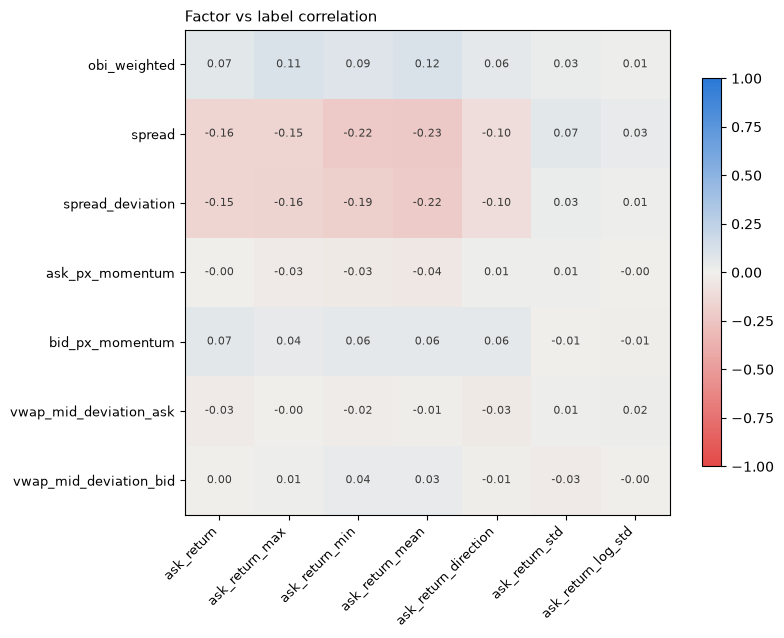

In [12]:
# factor -> label cross-correlation
visual.plot_cross_corr_heatmap(data_1s, factor_cols, labels_cols, 'Factor vs label correlation')

### Factor & Label Hyperparameter Tuning

Correlation-based factor hyperparameter tuning. This section explores how the correlation between factors and labels changes as factor hyperparameters vary. All labels share a single hyperparameter, `look_forward_ticks`.

Takeaways:
- Factors show decent correlation with the labels when tuned properly.
- A model can be constructed to predict `ask_return_direction` and `ask_return_std`.
- A trading signal can be constructed as `predicted_direction * predicted_log_std` (or predicted probability of price direction): an upward direction (ask price expected to rise) with a large std indicates a significant price increase — trade now; a downward direction with a large std indicates a significant price drop — wait.


In [13]:
print(f"Default (naive) hyperparameters for factors:")
display(factors_generator.factor_hyperparameters)

print(f"\nDefault (naive) hyperparameters for labels:")
display(labels_generator.label_hyperparameters)

Default (naive) hyperparameters for factors:


{'obi_weighted': {'level_weights': (50, 30, 20)},
 'spread': {},
 'spread_deviation': {'look_back_ticks': 100},
 'ask_px_momentum': {'lag_ticks': 100},
 'bid_px_momentum': {'lag_ticks': 100},
 'vwap_mid_deviation_ask': {'look_back_ticks': 100,
  'level_weights': (85, 10, 5)},
 'vwap_mid_deviation_bid': {'look_back_ticks': 100,
  'level_weights': (85, 10, 5)}}


Default (naive) hyperparameters for labels:


{'ask_return': {'look_forward_ticks': 100},
 'ask_return_max': {'look_forward_ticks': 100},
 'ask_return_min': {'look_forward_ticks': 100},
 'ask_return_mean': {'look_forward_ticks': 100},
 'ask_return_direction': {'look_forward_ticks': 100},
 'ask_return_std': {'look_forward_ticks': 100},
 'ask_return_log_std': {'look_forward_ticks': 100}}

In [14]:
from execution_timing.feature_engineering import grid_search_factors

LEVEL_WEIGHTS_GRID = [(100,0,0), (80,20,0), (70,20,10), (50,30,20), (34,33,33)]
FACTOR_GRID = {
    'obi_weighted':          {'level_weights':   LEVEL_WEIGHTS_GRID},
    'spread':                {},
    'spread_deviation':      {'look_back_ticks': [50, 100, 300, 600, 1000]},
    'ask_px_momentum':       {'lag_ticks':       [50, 100, 300, 600, 1000]},
    'bid_px_momentum':       {'lag_ticks':       [50, 100, 300, 600, 1000]},
    'vwap_mid_deviation_ask':{'look_back_ticks': [30, 100, 300],
                                'level_weights':   LEVEL_WEIGHTS_GRID},
    'vwap_mid_deviation_bid':{'look_back_ticks': [30, 100, 300],
                                'level_weights':   LEVEL_WEIGHTS_GRID},
  }

# All labels share the same forecast horizon; it defines the prediction
# problem (execution deadline), so it is fixed rather than grid-searched
LOOK_FORWARD_TICKS = 100

# correlation of every factor-hyperparameter variant against every label
corr = grid_search_factors(data=data, # do not use resampled data here!
                           factor_grid=FACTOR_GRID,
                           look_forward_ticks=LOOK_FORWARD_TICKS,
                           resample_freq='1s').sort_index()
abs_corr = corr.abs()
display(corr)

,ask_return,ask_return_max,ask_return_min,ask_return_mean,ask_return_direction,ask_return_std,ask_return_log_std
ask_px_momentum|lag_ticks=100,-0.002684,-0.030197,-0.032702,-0.041036,0.008663,0.008129,-0.003423
ask_px_momentum|lag_ticks=1000,-0.011105,-0.036128,0.002110,-0.015647,-0.000511,-0.032012,-0.020627
ask_px_momentum|lag_ticks=300,0.000811,-0.036653,-0.015797,-0.026746,0.011240,-0.018938,-0.004707
ask_px_momentum|lag_ticks=50,-0.039811,-0.056654,-0.069178,-0.079885,-0.012895,0.012910,-0.008125
ask_px_momentum|lag_ticks=600,-0.004871,-0.036156,-0.000587,-0.017213,0.002857,-0.029794,-0.020823
bid_px_momentum|lag_ticks=100,0.066917,0.043331,0.056861,0.057040,0.056554,-0.005460,-0.009351
bid_px_momentum|lag_ticks=1000,0.009482,-0.016750,0.028905,0.012880,0.012564,-0.039232,-0.024263
bid_px_momentum|lag_ticks=300,0.042493,0.008321,0.036128,0.031439,0.041043,-0.023254,-0.005663
bid_px_momentum|lag_ticks=50,0.049821,0.043735,0.050117,0.053420,0.048508,-0.008228,-0.013488
bid_px_momentum|lag_ticks=600,0.018907,-0.011980,0.030804,0.017083,0.019488,-0.036098,-0.022869


In [15]:
# best variant per factor column per label, by absolute correlation
factor_base = abs_corr.index.str.split('|').str[0]
best_variant = abs_corr.groupby(factor_base).idxmax()
display(best_variant)

,ask_return,ask_return_max,ask_return_min,ask_return_mean,ask_return_direction,ask_return_std,ask_return_log_std
ask_px_momentum,ask_px_momentum|lag_ticks=50,ask_px_momentum|lag_ticks=50,ask_px_momentum|lag_ticks=50,ask_px_momentum|lag_ticks=50,ask_px_momentum|lag_ticks=50,ask_px_momentum|lag_ticks=1000,ask_px_momentum|lag_ticks=600
bid_px_momentum,bid_px_momentum|lag_ticks=100,bid_px_momentum|lag_ticks=50,bid_px_momentum|lag_ticks=100,bid_px_momentum|lag_ticks=100,bid_px_momentum|lag_ticks=100,bid_px_momentum|lag_ticks=1000,bid_px_momentum|lag_ticks=1000
obi_weighted,"obi_weighted|level_weights=(100, 0, 0)","obi_weighted|level_weights=(80, 20, 0)","obi_weighted|level_weights=(100, 0, 0)","obi_weighted|level_weights=(100, 0, 0)","obi_weighted|level_weights=(80, 20, 0)","obi_weighted|level_weights=(34, 33, 33)","obi_weighted|level_weights=(34, 33, 33)"
spread,spread|,spread|,spread|,spread|,spread|,spread|,spread|
spread_deviation,spread_deviation|look_back_ticks=300,spread_deviation|look_back_ticks=300,spread_deviation|look_back_ticks=1000,spread_deviation|look_back_ticks=600,spread_deviation|look_back_ticks=300,spread_deviation|look_back_ticks=1000,spread_deviation|look_back_ticks=1000
vwap_mid_deviation_ask,"vwap_mid_deviation_ask|look_back_ticks=30,leve...","vwap_mid_deviation_ask|look_back_ticks=30,leve...","vwap_mid_deviation_ask|look_back_ticks=30,leve...","vwap_mid_deviation_ask|look_back_ticks=30,leve...","vwap_mid_deviation_ask|look_back_ticks=300,lev...","vwap_mid_deviation_ask|look_back_ticks=30,leve...","vwap_mid_deviation_ask|look_back_ticks=30,leve..."
vwap_mid_deviation_bid,"vwap_mid_deviation_bid|look_back_ticks=30,leve...","vwap_mid_deviation_bid|look_back_ticks=30,leve...","vwap_mid_deviation_bid|look_back_ticks=30,leve...","vwap_mid_deviation_bid|look_back_ticks=30,leve...","vwap_mid_deviation_bid|look_back_ticks=30,leve...","vwap_mid_deviation_bid|look_back_ticks=30,leve...","vwap_mid_deviation_bid|look_back_ticks=30,leve..."


In [16]:
best_corr = abs_corr.groupby(factor_base).max()
display(best_corr.round(4))

,ask_return,ask_return_max,ask_return_min,ask_return_mean,ask_return_direction,ask_return_std,ask_return_log_std
ask_px_momentum,0.0398,0.0567,0.0692,0.0799,0.0129,0.0320,0.0208
bid_px_momentum,0.0669,0.0437,0.0569,0.0570,0.0566,0.0392,0.0243
obi_weighted,0.0939,0.1280,0.1275,0.1499,0.0717,0.0357,0.0157
spread,0.1556,0.1503,0.2217,0.2290,0.1036,0.0678,0.0326
spread_deviation,0.1601,0.1703,0.2118,0.2303,0.1097,0.0398,0.0158
vwap_mid_deviation_ask,0.0559,0.0332,0.0697,0.0660,0.0386,0.0336,0.0265
vwap_mid_deviation_bid,0.0755,0.0657,0.1268,0.1202,0.0459,0.0616,0.0311


In [17]:
# best (initial) hyperparameters for factors
# should be fine-tuned later
factor_hyperparameters = {
    'obi_weighted': {'level_weights': (80, 20, 0)},
    'spread': {},
    'spread_deviation': {'look_back_ticks': 300},
    'ask_px_momentum': {'lag_ticks': 50}, # 50 for ask_return_direction; 600 for ask_return_log_std
    'bid_px_momentum': {'lag_ticks': 50}, # 50 for ask_return_direction; 600 for ask_return_log_std
    'vwap_mid_deviation_ask': {'look_back_ticks': 30,
                               'level_weights': (100, 0, 0)},
    'vwap_mid_deviation_bid': {'look_back_ticks': 30,
                               'level_weights': (100, 0, 0)},
}